# Mini Project 3 - Text Classification

## Classifying mental health comments into categories 

#### Importing libararies to conduct text classification

In [234]:
## Import Libraries
import numpy as np
import pandas as pd

import string
import spacy
import regex as re
import contractions

%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from wordcloud import WordCloud, STOPWORDS

from collections import Counter

from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report

import warnings
warnings.filterwarnings('ignore')

### Exploratory Data Analysis

In [394]:
#Reading csv file into dataframe
df = pd.read_csv('mental_health_combined_test.csv')
df.sample(10)

,text,status
352,"sounds weird, right? but lately i've been so d...",Depression
193,(in informal settings when there is sun obviou...,Anxiety
242,i don’t know if this has been posted on this t...,Anxiety
778,I've just about had it.Life is short. Too shor...,Suicidal
897,People who would Care if I diedThe only people...,Suicidal
577,All lives can't matter until black lives matte...,Normal
112,my wife passed out from a panic attack yesterd...,Anxiety
203,"which is, now, the longest i've gone without a...",Anxiety
605,Hello there My name Ragnikant Babu From Indian...,Normal
701,I've got suspended for a joke and I'm pissed W...,Normal


In [395]:
#value count for status
df['status'].value_counts()

status
Anxiety       248
Depression    248
Normal        248
Suicidal      248
Name: count, dtype: int64

In [396]:
#Applying cleaning function to text data
def clean_text(text):
    # reduce multiple spaces and newlines to only one
    text = re.sub(r'(\s\s+|\n\n+)', r'\1', text)
    # remove double quotes
    text = re.sub(r'"', '', text)

    return text

df['text'] = df['text'].apply(clean_text)

In [397]:
df.head()

,text,status
0,i don't understand whats wrong with me. i don'...,Anxiety
1,usually when i have anxiety just chatting with...,Anxiety
2,"well, i've had anxiety and panic syndrome for ...",Anxiety
3,"for the most minimal of things, like standing ...",Anxiety
4,i stay away from family and live with my roomm...,Anxiety


In [398]:
df['text'] = df['text'].apply(lambda x: contractions.fix(str(x)))

In [399]:
df.sample(10)

,text,status
314,"you are depressed! you are okay, it will take ...",Depression
220,i ordered a pizza online but after i submitted...,Anxiety
248,i am talking about the kind of people who woul...,Depression
780,"I have considered suicide, but realized it wou...",Suicidal
731,Who. Wants. My. Goddamn. Hugz. Award Say somet...,Normal
759,:(i literally cannot remember the last time i ...,Suicidal
227,for example: let us say i have this appointmen...,Anxiety
974,I cannot live like this anymore.I am dying ins...,Suicidal
104,making friends is something i am legitimately ...,Anxiety
452,"whether it is people, places or phases in life...",Depression


In [400]:
nlp = spacy.load('en_core_web_sm')

In [401]:
#function to remove stop words, numbers, and punctuation, while retaining proper nouns
# and lemmatizing words
def convert_text(text):
    sent = nlp(text)
    ents = {x.text: x for x in sent.ents}
    tokens = []
    for w in sent:
        if w.is_stop or w.is_punct or w.is_digit:
            continue
        if w.text in ents:
            tokens.append(w.text)
        else:
            tokens.append(w.lemma_.lower())
    text = ' '.join(tokens)
    
    return text

In [402]:
%%time
df['short'] = df['text'].apply(convert_text)

CPU times: user 21 s, sys: 1.78 s, total: 22.8 s
Wall time: 22.9 s


In [403]:
df["short"] = df["short"].str.replace(
    r"[^a-zA-Z0-9 ]", " ", regex=True
)

In [405]:
df.sample(10)

,text,status,short
346,i pretty much do not know where to go at this ...,Depression,pretty know point tell thing bad thing actuall...
430,i usually do not wash or fold unless i absolut...,Depression,usually wash fold absolutely typically look li...
349,after having to take a medical leave from a go...,Depression,have medical leave good college depression soc...
303,this is becoming a problem. this is not the fi...,Depression,problem time happen surprised fire unmotivated...
974,I cannot live like this anymore.I am dying ins...,Suicidal,live like anymore die inside go right anymore ...
307,i did not wake up yesterday until 6pm. i laid ...,Depression,wake yesterday pm lay bed wake buy case beer p...
616,There were a lot of moms protesting quarintine...,Normal,lot mom protest quarintine area start quarinti...
867,Is this legitIn comments is the link. If I bou...,Suicidal,legitin comment link buy take actually kill
334,"my depression has the opposite effect on me, i...",Depression,depression opposite effect make want eat lot t...
623,my judgement has finally come... according to ...,Normal,judgement finally come accord r teenamiugly ...


In [406]:
#filtering data by target status
#setting targets
target_anxiety = 'Anxiety'
target_depression ='Depression'
target_normal ='Normal'
target_suicidal ='Suicidal'

#Creating df by target status
anxiety_df = df[df['status'] == target_anxiety]
depression_df = df[df['status'] == target_depression]
normal_df = df[df['status'] == target_normal]
suicidal_df = df[df['status'] == target_suicidal]

#Joining all rows into one cell
anxiety_data = " ".join(anxiety_df["short"].dropna().astype(str))
depression_data = " ".join(depression_df["short"].dropna().astype(str))
normal_data = " ".join(normal_df["short"].dropna().astype(str))
suicidal_data = " ".join(suicidal_df["short"].dropna().astype(str))

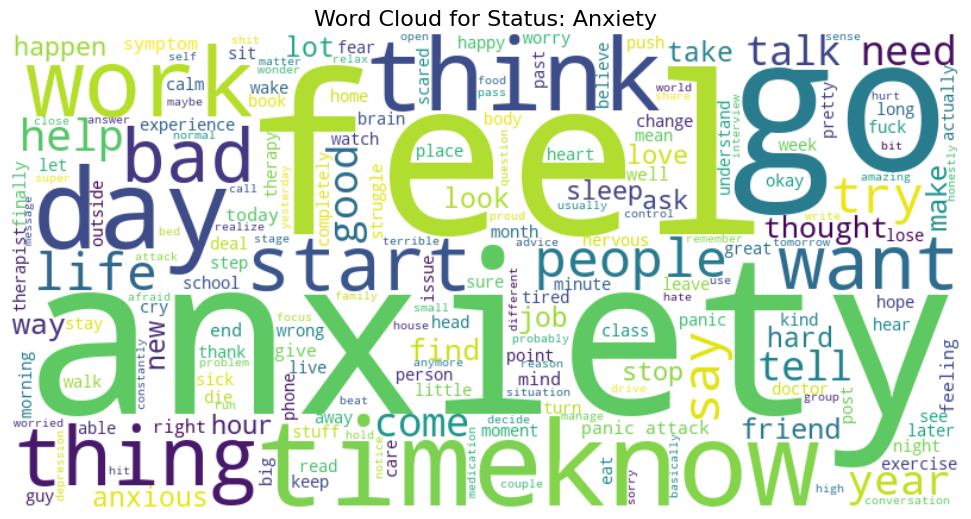

In [407]:
# Configure and generate the word cloud for anxiety
# Adding default STOPWORDS filters out common filler words like 'and', 'the', 'is'
wordcloud_anxiety = WordCloud(
    width=800,
    height=400,
    background_color="white",
    stopwords=set(STOPWORDS),
    colormap="viridis",  
    min_font_size=10,
).generate(anxiety_data)

#Display the final visualization using Matplotlib
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_anxiety, interpolation="bilinear")
plt.axis("off")  # Hides x and y axis coordinates for a clean visual
plt.title(f"Word Cloud for Status: {target_anxiety.capitalize()}", fontsize=16)
plt.tight_layout(pad=0)
plt.show()

In [408]:
#Finding frequency of words for anxiety data
anxiety_data_split = anxiety_data.split()
anxiety_data_count = Counter(anxiety_data_split)
anxiety_data_top = anxiety_data_count.most_common(10)
anxiety_data_top

#creating dataframe for top 10 words
anxiety_data_top = pd.DataFrame(anxiety_data_top, columns=['Word', 'Count'])
anxiety_data_top.index = ['1', '2', '3', '4', '5', '6', '7', '8', '9', '10']
anxiety_data_top

,Word,Count
1,anxiety,340
2,feel,318
3,like,286
4,go,210
5,time,205
6,know,194
7,think,163
8,day,157
9,work,149
10,thing,147


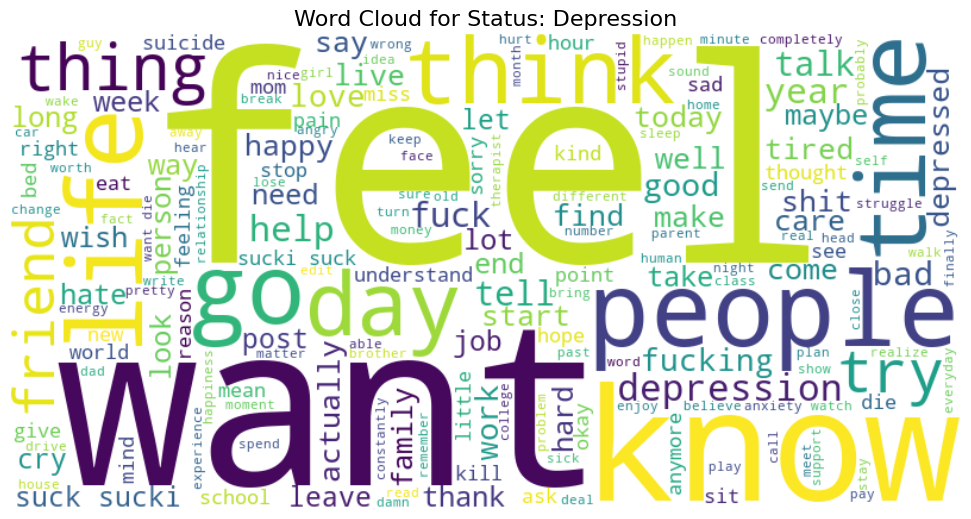

In [409]:
# Configure and generate the word cloud for depression
# Adding default STOPWORDS filters out common filler words like 'and', 'the', 'is'
wordcloud_depression = WordCloud(
    width=800,
    height=400,
    background_color="white",
    stopwords=set(STOPWORDS),
    colormap="viridis",  
    min_font_size=10,
).generate(depression_data)

# Display the final visualization using Matplotlib
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_depression, interpolation="bilinear")
plt.axis("off")  # Hides x and y axis coordinates for a clean visual
plt.title(f"Word Cloud for Status: {target_depression.capitalize()}", fontsize=16)
plt.tight_layout(pad=0)
plt.show()

In [365]:
#Finding frequency of words for depression data
depression_data_split = depression_data.split()
depression_data_count = Counter(depression_data_split)
depression_data_top = depression_data_count.most_common(10)

#creating dataframe for top 10 words
depression_data_top = pd.DataFrame(depression_data_top, columns=['Word', 'Count'])
depression_data_top.index = ['1', '2', '3', '4', '5', '6', '7', '8', '9', '10']
depression_data_top

,Word,Count
1,feel,311
2,like,254
3,want,192
4,know,164
5,people,162
6,life,162
7,time,158
8,go,144
9,day,142
10,think,136


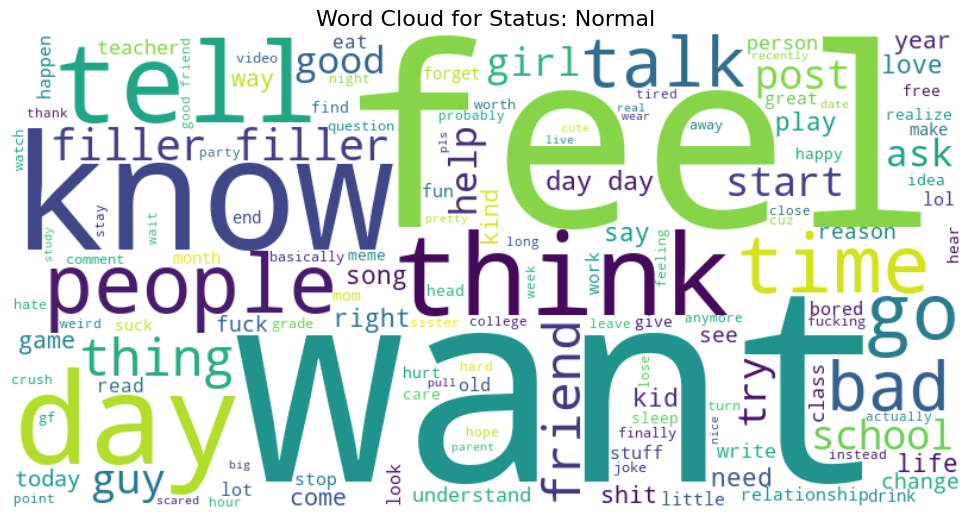

In [366]:
# Configure and generate the word cloud for normal
# Adding default STOPWORDS filters out common filler words like 'and', 'the', 'is'
wordcloud_normal = WordCloud(
    width=800,
    height=400,
    background_color="white",
    stopwords=set(STOPWORDS),
    colormap="viridis",  
    min_font_size=10,
).generate(normal_data)

# Display the final visualization using Matplotlib
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_normal, interpolation="bilinear")
plt.axis("off")  # Hides x and y axis coordinates for a clean visual
plt.title(f"Word Cloud for Status: {target_normal.capitalize()}", fontsize=16)
plt.tight_layout(pad=0)
plt.show()

In [367]:
#Finding frequency of words for normal data
normal_data_split = normal_data.split()
normal_data_count = Counter(normal_data_split)
normal_data_top = normal_data_count.most_common(10)

#creating dataframe for top 10 words
normal_data_top = pd.DataFrame(normal_data_top, columns=['Word', 'Count'])
normal_data_top.index = ['1', '2', '3', '4', '5', '6', '7', '8', '9', '10']
normal_data_top

,Word,Count
1,like,137
2,day,121
3,want,89
4,feel,69
5,know,68
6,friend,51
7,think,50
8,tell,48
9,people,43
10,get,43


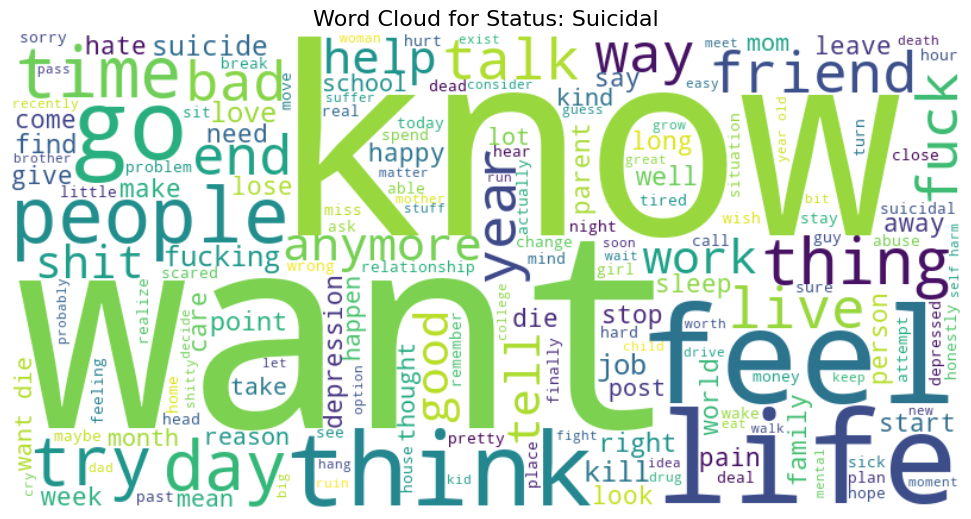

In [368]:
# Configure and generate the word cloud for Suicidal
# Adding default STOPWORDS filters out common filler words like 'and', 'the', 'is'
wordcloud_suicidal = WordCloud(
    width=800,
    height=400,
    background_color="white",
    stopwords=set(STOPWORDS),
    colormap="viridis",  
    min_font_size=10,
).generate(suicidal_data)

# Display the final visualization using Matplotlib
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud_suicidal, interpolation="bilinear")
plt.axis("off")  # Hides x and y axis coordinates for a clean visual
plt.title(f"Word Cloud for Status: {target_suicidal.capitalize()}", fontsize=16)
plt.tight_layout(pad=0)
plt.show()

In [369]:
#Finding frequency of words for anxiety data
suicidal_data_split = suicidal_data.split()
suicidal_data_count = Counter(suicidal_data_split)
suicidal_data_top = suicidal_data_count.most_common(10)

#creating dataframe for top 10 words
df_suicidal_data_top = pd.DataFrame(suicidal_data_top, columns=['Word', 'Count'])
df_suicidal_data_top.index = ['1', '2', '3', '4', '5', '6', '7', '8', '9', '10']
df_suicidal_data_top

,Word,Count
1,want,360
2,like,323
3,know,275
4,feel,272
5,life,262
6,think,212
7,go,193
8,people,183
9,time,180
10,get,153


#### Feature Engineering keywords: Anxiety, Suicide, Depression

In [411]:
keywords = ['anxiety', 'anxious', 'suicide', 'suicidal', 'depress', 'depression']

for kw in keywords:
    df[f'flag_{kw}'] = df['short'].str.contains(kw, case=False, na=False, regex=False).astype(int)


#### Applying Text Classifcation models

In [371]:
#Previewing new dataframe
df.sample(5)

,text,status,short,flag_anxiety,flag_anxious,flag_suicide,flag_suicidal,flag_depress,flag_depression
231,my therapist said that i did not need him anym...,Anxiety,therapist say need anymore say improve bi mont...,1,0,0,0,0,0
659,Just did a pact with my best friend If neither...,Normal,pact good friend married relationship age adop...,0,0,0,0,0,0
224,the thought of my spouse dying is the main thi...,Anxiety,thought spouse dying main thing give high anxi...,1,0,0,0,0,0
936,please tell me how to kill myself.please tell ...,Suicidal,tell kill myselfplease tell reliably kill pain...,0,0,0,0,0,0
482,i make a lot of mistakes and am very awkward s...,Depression,lot mistake awkward end think word kill dozens...,0,0,0,0,0,0


#### Setting features and labels using cleaned_short text

In [372]:
# Setting Features and Labels using cleaned_short text
X = df['short']
y = df['status']

# Apply a train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 42)

In [373]:
X_train

938    give lifeive life month life actually beautifu...
572    guy sixth grade class convince jack rub jaw mu...
926    slowly happy suicide depression supress gym st...
404    feel like lately terrify tell head true merely...
526    life disappointment  play ball foot game lift ...
                             ...                        
106    find matter write reply post social medium hon...
270    depression little year go med therapist life c...
860    go end sooni know try kill like month ago fail...
435    take number ssris depressive episode wellbutri...
102    think have great time have fun regret say hate...
Name: short, Length: 694, dtype: object

In [374]:
y_train

938      Suicidal
572        Normal
926      Suicidal
404    Depression
526        Normal
          ...    
106       Anxiety
270    Depression
860      Suicidal
435    Depression
102       Anxiety
Name: status, Length: 694, dtype: object

#### Creating Pipelines to implement classification models

In [375]:
pipeMNB = Pipeline([('tfidf', TfidfVectorizer(ngram_range=(1, 3), min_df=2)), ('clf', MultinomialNB())])
pipeCNB = Pipeline([('tfidf', TfidfVectorizer(ngram_range=(1, 3), min_df=2)), ('clf', ComplementNB())])
pipeRF = Pipeline([('tfidf', TfidfVectorizer(ngram_range=(1, 3), min_df=2)), ('clf', RandomForestClassifier())])
pipeGBC = Pipeline([('tfidf', TfidfVectorizer(ngram_range=(1, 3), min_df=2)), ('clf', GradientBoostingClassifier())])
pipeSVC = Pipeline([('tfidf', TfidfVectorizer(ngram_range=(1, 3), min_df=2)), ('clf', LinearSVC())])

In [376]:
pipeMNB.fit(X_train, y_train)
predictMNB = pipeMNB.predict(X_test)
accuracy_score_MNB = accuracy_score(y_test, predictMNB)

In [377]:
pipeRF.fit(X_train, y_train)
predictRF = pipeRF.predict(X_test)
accuracy_score_RF = accuracy_score(y_test, predictRF)

In [378]:
pipeGBC.fit(X_train, y_train)
pipeGBC = pipeGBC.predict(X_test)
accuracy_score_GBC = accuracy_score(y_test, pipeGBC)

In [379]:
pipeSVC.fit(X_train, y_train)
pipeSVC = pipeSVC.predict(X_test)
accuracy_score_SVC = accuracy_score(y_test, pipeSVC)

In [380]:
pipeCNB.fit(X_train, y_train)
predictCNB = pipeCNB.predict(X_test)
accuracy_score_CNB = accuracy_score(y_test, predictCNB)

In [381]:
print(f"MultinomialNB: {accuracy_score_MNB:.3f}")
print(f"RandomForestClassifier: {accuracy_score_RF:.3f}")
print(f"GradientBoostingClassifier: {accuracy_score_GBC:.3f}")
print(f"LinearSVC: {accuracy_score_SVC:.3f}")
print(f"ComplementNB: {accuracy_score_CNB:.3f}")

MultinomialNB: 0.550
RandomForestClassifier: 0.570
GradientBoostingClassifier: 0.631
LinearSVC: 0.641
ComplementNB: 0.577


In [382]:
#Creating classification report for SVC model 
print(classification_report(y_test, pipeSVC))

              precision    recall  f1-score   support

     Anxiety       0.66      0.66      0.66        70
  Depression       0.58      0.53      0.55        77
      Normal       0.70      0.76      0.73        74
    Suicidal       0.62      0.62      0.62        77

    accuracy                           0.64       298
   macro avg       0.64      0.64      0.64       298
weighted avg       0.64      0.64      0.64       298



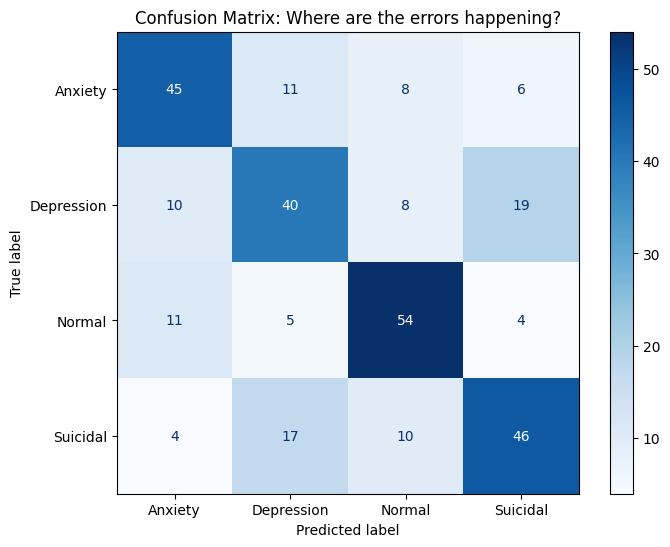

In [176]:
from sklearn.metrics import ConfusionMatrixDisplay

# Generate and plot the matrix
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test, 
    pipeSVC, 
    display_labels=['Anxiety', 'Depression', 'Normal', 'Suicidal'],
    cmap=plt.cm.Blues,
    ax=ax
)

plt.title("Confusion Matrix: Where are the errors happening?")
plt.show()

#### Setting features and labels using cleaned_short text and feature engineered variables

In [412]:
#Previewing new dataframe
df.sample(3)

,text,status,short,flag_anxiety,flag_anxious,flag_suicide,flag_suicidal,flag_depress,flag_depression
659,Just did a pact with my best friend If neither...,Normal,pact good friend married relationship age adop...,0,0,0,0,0,0
277,the most popular girl in our entire school her...,Depression,popular girl entire school go brag depressed c...,0,0,0,0,1,0
528,Does anyone need to talk I feel like playing t...,Normal,need talk feel like play therapist right want ...,0,0,0,0,0,0


In [413]:
# Setting Features and Labels using cleaned_short text
X2 = df[['short','flag_anxiety','flag_anxious','flag_suicide','flag_suicidal','flag_depress','flag_depression']]
y2 = df['status']

# Apply a train-test split
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size = 0.3, random_state = 42)

In [414]:
X2_train

,short,flag_anxiety,flag_anxious,flag_suicide,flag_suicidal,flag_depress,flag_depression
938,give lifei ve life month life actually beautif...,0,0,0,0,0,0
572,guy sixth grade class convince jack rub jaw mu...,0,0,0,0,0,0
926,slowly happy suicide depression supress gym st...,0,0,1,0,1,1
404,feel like lately terrify tell head true merely...,0,0,0,0,0,0
526,life disappointment play ball foot game lift...,0,0,0,0,0,0
...,...,...,...,...,...,...,...
106,find matter write reply post social medium hon...,1,0,0,0,0,0
270,depression little year go med therapist life c...,0,0,0,0,1,1
860,go end sooni know try kill like month ago fail...,0,0,1,0,0,0
435,take number ssris depressive episode wellbutri...,0,0,0,0,1,1


In [415]:
y2_train

938      Suicidal
572        Normal
926      Suicidal
404    Depression
526        Normal
          ...    
106       Anxiety
270    Depression
860      Suicidal
435    Depression
102       Anxiety
Name: status, Length: 694, dtype: object

In [416]:
numeric_features = ['flag_anxiety','flag_anxious','flag_suicide','flag_suicidal',
                    'flag_depress','flag_depression']

In [417]:
preprocessor = ColumnTransformer(
    transformers=[
        ('text_tfidf', TfidfVectorizer(ngram_range=(1, 3)), 'short'),
        ('numeric_scaler', StandardScaler(), numeric_features)
    ])

In [418]:
pipeSVC2 = Pipeline([('preprocessor', preprocessor), ('clf', LinearSVC())])
pipeRF2 = Pipeline([('preprocessor', preprocessor), ('clf', RandomForestClassifier())])
pipeGBC2 = Pipeline([('preprocessor', preprocessor), ('clf', GradientBoostingClassifier())])
pipeGNB2 = Pipeline([('preprocessor', preprocessor), ('clf', GaussianNB())])


In [419]:
pipeSVC2.fit(X2_train, y2_train)
pipeSVC_2 = pipeSVC2.predict(X2_test)
accuracy_score_SVC_2 = accuracy_score(y2_test, pipeSVC_2)
print(f"LinearSVC: {accuracy_score_SVC_2:.3f}")

LinearSVC: 0.644


In [420]:
pipeRF2.fit(X2_train, y2_train)
pipeRF_2 = pipeRF2.predict(X2_test)
accuracy_score_RF_2 = accuracy_score(y2_test, pipeRF_2)
print(f"RandomForestClassifier: {accuracy_score_RF_2:.3f}")

RandomForestClassifier: 0.584


In [421]:
pipeGBC2.fit(X2_train, y2_train)
pipeGBC_2 = pipeGBC2.predict(X2_test)
accuracy_score_GBC_2 = accuracy_score(y2_test, pipeGBC_2)
print(f"GradientBoostingClassifier: {accuracy_score_GBC_2:.3f}")

GradientBoostingClassifier: 0.624


In [422]:
#Creating classification report for SVC model 
print(classification_report(y2_test, pipeSVC_2))

              precision    recall  f1-score   support

     Anxiety       0.73      0.64      0.68        70
  Depression       0.57      0.49      0.53        77
      Normal       0.73      0.80      0.76        74
    Suicidal       0.57      0.65      0.61        77

    accuracy                           0.64       298
   macro avg       0.65      0.65      0.64       298
weighted avg       0.64      0.64      0.64       298



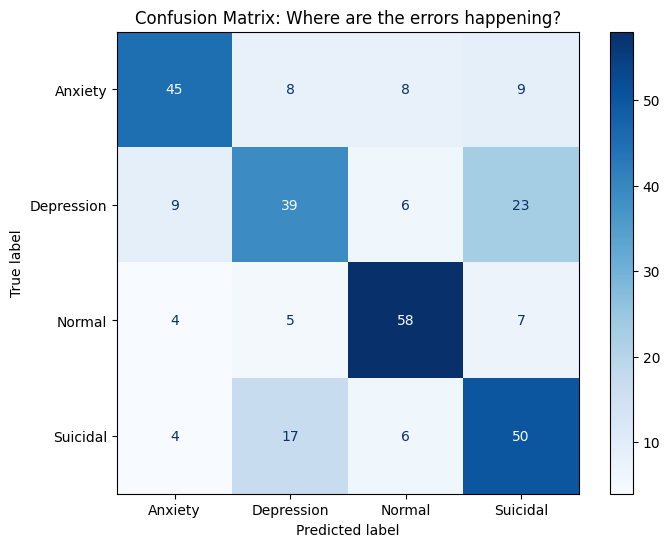

In [194]:
# Generate and plot the matrix
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    y2_test, 
    pipeSVC_2, 
    display_labels=['Anxiety', 'Depression', 'Normal', 'Suicidal'],
    cmap=plt.cm.Blues,
    ax=ax
)

plt.title("Confusion Matrix: Where are the errors happening?")
plt.show()

### Conclusion

- The best performing model for text classification was Linear Support Vector Machines with an accuracy score of 64.4%, using feature engineering.     
- Using feature engineering only added minor improvement (0.3%) With only an 64.4% accuracy score and the consequences of misdiagnosis, I would not recommend any of the text classification models currently designed
  
- Next Steps: Create other features such as word count, word density, character count, etc. Use other text cleaning methods:     
    - Keeping stop words may help capture nuances of mental health status
